In [1]:
import numpy as np
import pandas as pd
 
import matplotlib.pyplot as plt
%matplotlib inline
 

In [4]:
df = pd.read_csv(r"C:\Users\abdul\Documents\BIA\ML\Dataset\timeseries.csv")

In [5]:
df.head()

,Month,Perrin Freres monthly champagne sales millions ?64-?72
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


In [6]:
## Cleaning up the data
df.columns=["Month","Sales"]
df.head()
 

,Month,Sales
0,1964-01,2815.0
1,1964-02,2672.0
2,1964-03,2755.0
3,1964-04,2721.0
4,1964-05,2946.0


In [15]:
## Drop last 2 rows
df.drop(104,axis=0,inplace=True)
 

In [14]:
df.tail()

,Month,Sales
100,1972-05,4618.0
101,1972-06,5312.0
102,1972-07,4298.0
103,1972-08,1413.0
104,1972-09,5877.0


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Month   104 non-null    str    
 1   Sales   104 non-null    float64
dtypes: float64(1), str(1)
memory usage: 2.5 KB


In [17]:
# Convert Month into Datetime
df['Month']=pd.to_datetime(df['Month'])
df.head()

,Month,Sales
0,1964-01-01,2815.0
1,1964-02-01,2672.0
2,1964-03-01,2755.0
3,1964-04-01,2721.0
4,1964-05-01,2946.0


In [18]:
df.set_index('Month',inplace=True)
 

<Axes: xlabel='Month'>

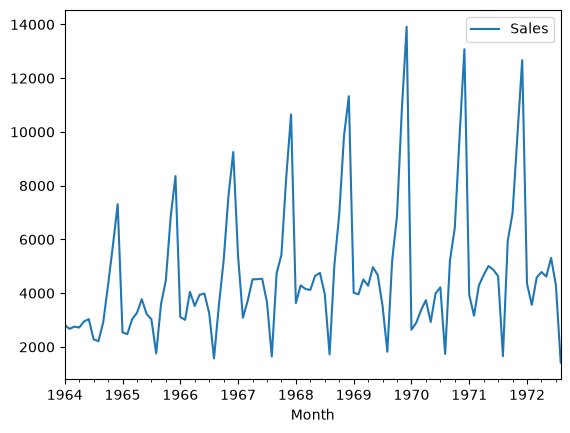

In [19]:
df.plot()

In [21]:
pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 5.0 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/11.3 MB 4.9 MB/s eta 0:00:02
   ----------- ---------------------------- 3.1/11.3 MB 5.5 MB/s eta 0:00:02
   ----------------- ---------------------- 5.0/11.3 MB 6.7 MB/s eta 0:00:01
   ------------------------ --------------- 6.8/11.3 MB 7.0 MB/s eta 0:00:01
   ------------------------------- -------- 8.9/11.3 MB 7.5 MB/s eta 0:00:01
   ------------------------------------ --- 10.2/11.3 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 7.4 MB/s  0:00:01

   ---------------------------------------- 0/5 [wrapt]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   ---------------- ----------------------- 2/5 [interface-meta]
   ----------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
### Testing For Stationarity
 
from statsmodels.tsa.stattools import adfuller
 
 

In [23]:
df['Sales']

Month
1964-01-01    2815.0
1964-02-01    2672.0
1964-03-01    2755.0
1964-04-01    2721.0
1964-05-01    2946.0
               ...  
1972-04-01    4788.0
1972-05-01    4618.0
1972-06-01    5312.0
1972-07-01    4298.0
1972-08-01    1413.0
Name: Sales, Length: 104, dtype: float64

In [26]:
#Ho: It is non stationary
#H1: It is stationary
 
def adfuller_test(sales):
    result=adfuller(sales)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    # for value,label in zip(result,labels):
    #     print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")
    
 

In [27]:
adfuller_test(df['Sales'])

weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


C:\Users\abdul\AppData\Local\Temp\ipykernel_4068\3035783176.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result=adfuller(sales)


In [28]:
df['Sales First Difference'] = df['Sales'] - df['Sales'].shift(1)
 

In [29]:
df['Sales First Difference']

Month
1964-01-01       NaN
1964-02-01    -143.0
1964-03-01      83.0
1964-04-01     -34.0
1964-05-01     225.0
               ...  
1972-04-01     211.0
1972-05-01    -170.0
1972-06-01     694.0
1972-07-01   -1014.0
1972-08-01   -2885.0
Name: Sales First Difference, Length: 104, dtype: float64

In [30]:
adfuller_test(df['Sales First Difference'].dropna())

strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


C:\Users\abdul\AppData\Local\Temp\ipykernel_4068\3035783176.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result=adfuller(sales)


<Axes: xlabel='Month'>

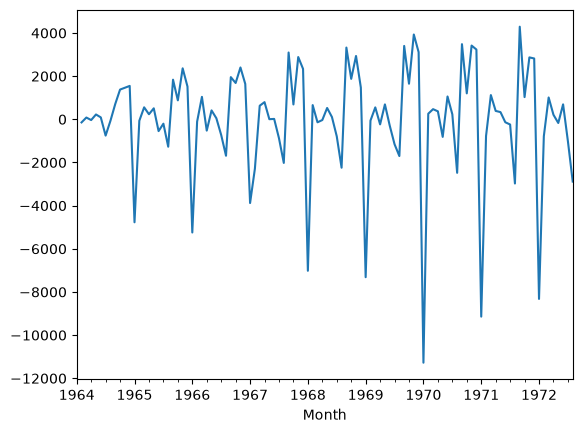

In [31]:
df["Sales First Difference"].plot()

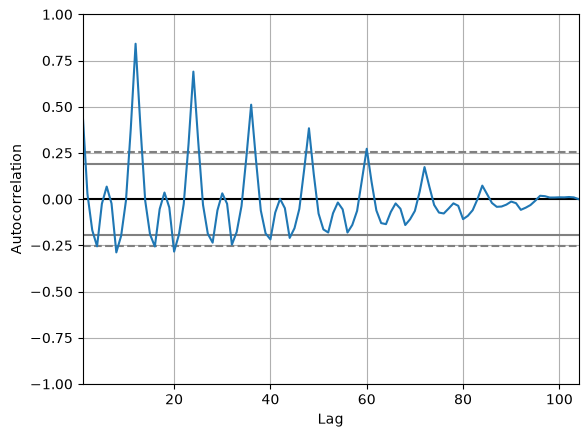

In [32]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df['Sales'])
plt.show()

In [33]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
 
 

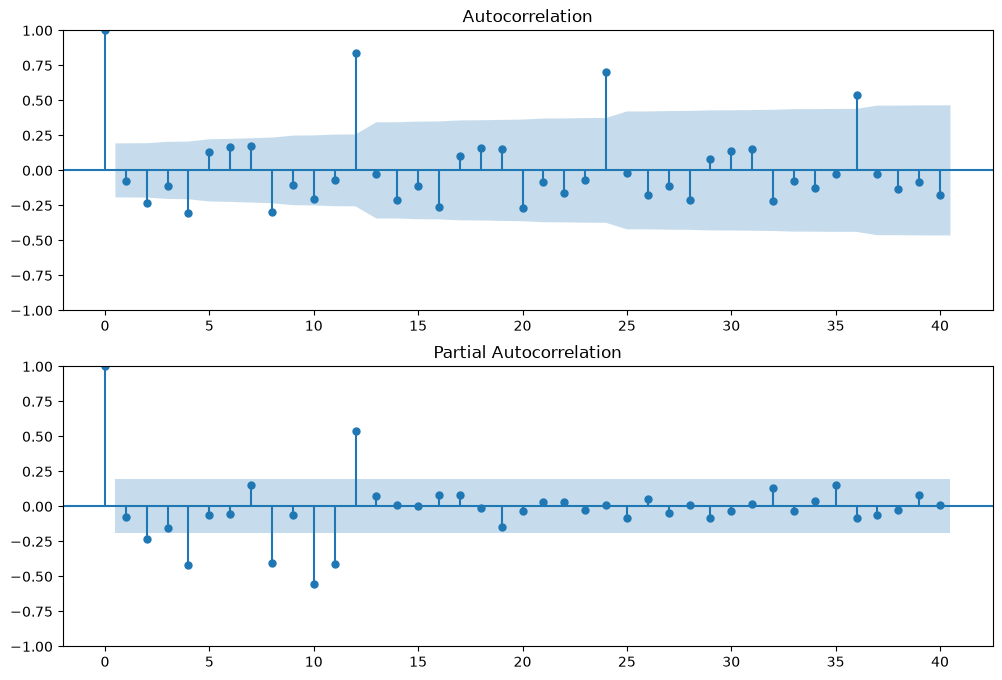

In [34]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = plot_acf(df['Sales First Difference'].iloc[1:],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = plot_pacf(df['Sales First Difference'].iloc[1:],lags=40,ax=ax2)
 

In [36]:
df['Seasonal First Difference']=df['Sales']-df['Sales'].shift(12)
 

In [37]:
df.head()

,Sales,Sales First Difference,Seasonal First Difference
Month,,,
1964-01-01,2815.0,NaN,NaN
1964-02-01,2672.0,-143.0,NaN
1964-03-01,2755.0,83.0,NaN
1964-04-01,2721.0,-34.0,NaN
1964-05-01,2946.0,225.0,NaN


In [38]:
from statsmodels.tsa.arima.model import ARIMA
 

In [ ]:
The forecasting at the server.model=ARIMA(df['Sales'],order=(2,1,1))
model_fit = model.fit()
 

c:\Users\abdul\Documents\BIA\bia_py_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\abdul\Documents\BIA\bia_py_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\abdul\Documents\BIA\bia_py_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [42]:
import statsmodels.api as sm
 

In [44]:
model=sm.tsa.statespace.SARIMAX(df['Sales'],order=(2, 1, 1),seasonal_order=(2,1,1,12))
results=model. fit()
 

c:\Users\abdul\Documents\BIA\bia_py_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\abdul\Documents\BIA\bia_py_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\abdul\Documents\BIA\bia_py_env\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


<Axes: xlabel='Month'>

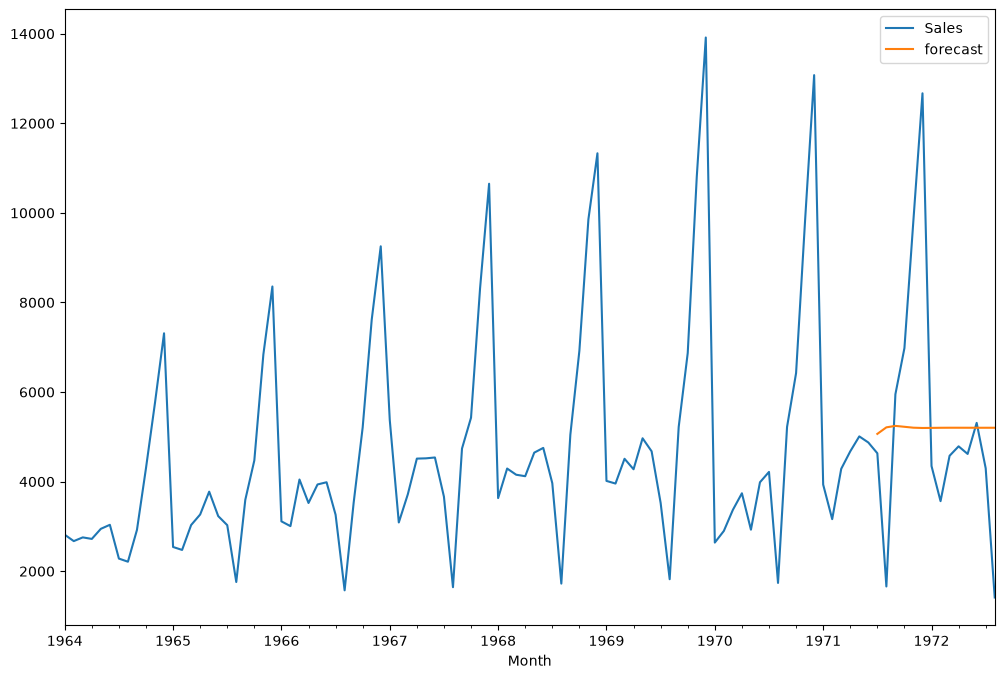

In [45]:
df['forecast']=model_fit.predict(start=90,end=103,dynamic=True)
df[['Sales','forecast']].plot(figsize=(12,8))
 

In [ ]:
#LM Studio
